# Voice Customer Support AI — Intent Routing
**Problem:** Customer support systems receive large numbers of user requests. Instead of manually routing every request, we automatically determine the **category** of the request from what the customer says.

**Workflow:** `Speech -> Text -> Preprocessing -> TF-IDF Vectorization -> ML Model -> Prediction + Confidence Score`

**Dataset:** [Bitext Customer Support Training Dataset](https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset) — 26,872 real, publicly available customer-support utterances, each labeled with a `category` (11 classes: ACCOUNT, ORDER, REFUND, INVOICE, CONTACT, PAYMENT, FEEDBACK, DELIVERY, SHIPPING, SUBSCRIPTION, CANCEL) and a fine-grained `intent` (27 classes). This notebook predicts `category` as the primary routing target.

## Step 1: Import Libraries

In [1]:
import sys
sys.path.insert(0, "..")  # so we can import src/preprocessing.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import joblib

from src.preprocessing import preprocess


## Step 2: Data Collection
Loading the real Bitext customer-support dataset (downloaded from Hugging Face).

In [2]:
df = pd.read_csv("../data/dataset.csv")
df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


## Step 3: Data Understanding

In [3]:
print(df.shape)
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nFully duplicate rows:", df.duplicated().sum())
print("\nDuplicate instruction text (paraphrases of the same request):", df["instruction"].duplicated().sum())
print("\nCategory distribution:\n", df["category"].value_counts())

(26872, 5)
<class 'pandas.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   flags        26872 non-null  str  
 1   instruction  26872 non-null  str  
 2   category     26872 non-null  str  
 3   intent       26872 non-null  str  
 4   response     26872 non-null  str  
dtypes: str(5)
memory usage: 1.0 MB

Missing values:
 flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

Fully duplicate rows: 0

Duplicate instruction text (paraphrases of the same request): 2237

Category distribution:
 category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


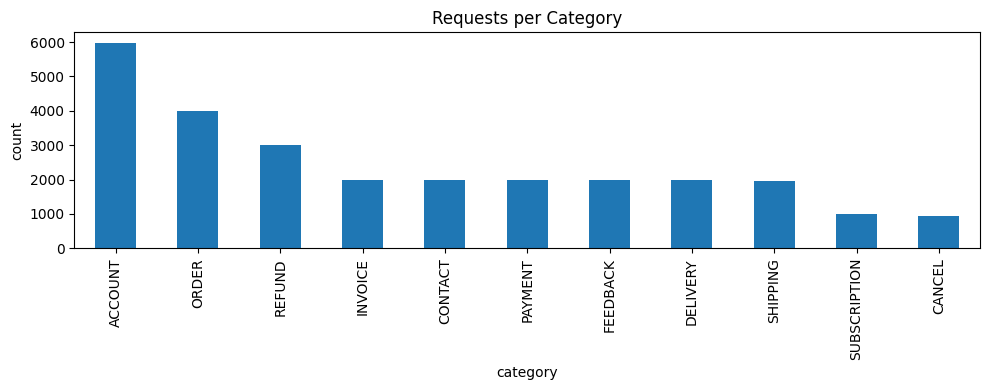

In [4]:
df["category"].value_counts().plot(kind="bar", figsize=(10,4), title="Requests per Category")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("../models/category_distribution.png")
plt.show()

**Observation:** classes are imbalanced (`ACCOUNT` has ~5,986 rows vs `CANCEL` at ~950). This is worth calling out explicitly when evaluating the model — accuracy alone can hide poor performance on the smaller classes, so we check per-class precision/recall/F1 below, not just overall accuracy.

## Step 4: Text Feature Engineering

In [5]:
df["char_count"] = df["instruction"].apply(len)
df["word_count"] = df["instruction"].apply(lambda x: len(x.split()))
df.groupby("category")[["char_count", "word_count"]].mean().round(1)

,char_count,word_count
category,,
ACCOUNT,45.4,8.3
CANCEL,44.0,8.2
CONTACT,44.0,8.8
DELIVERY,48.8,9.7
FEEDBACK,48.1,9.2
INVOICE,45.9,9.1
ORDER,46.8,8.2
PAYMENT,47.4,8.6
REFUND,50.7,9.5


## Step 5: Word Cloud

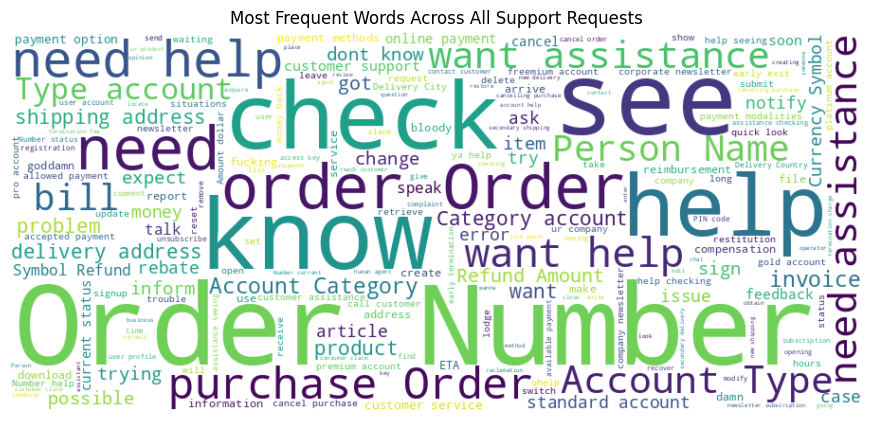

In [6]:
all_text = " ".join(df["instruction"].astype(str))
wordcloud = WordCloud(width=900, height=400, background_color="white").generate(all_text)

plt.figure(figsize=(11, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words Across All Support Requests")
plt.savefig("../models/wordcloud.png", bbox_inches="tight")
plt.show()

## Step 6: Text Preprocessing
Uses the shared `preprocess()` function from `src/preprocessing.py` — the same function `app.py` calls at inference time. Beyond the standard steps (lowercase, punctuation/number removal, stopword removal, lemmatization), it also strips Bitext's `{{Order Number}}`-style template placeholders, since a real spoken request would never contain that literal text.

In [7]:
df["clean_text"] = df["instruction"].apply(preprocess)
df[["instruction", "clean_text"]].sample(5, random_state=1)

,instruction,clean_text
4476,how can I check bill #12588?,check bill
676,I'm rtying to cancel order {{Order Number}},rtying cancel order
16877,I do not know what to do to demand my money back,know demand money back
26429,assistance to see if there are any news on the...,assistance see news refund
22508,I don't know how t leave an opinion about a pr...,know leave opinion product


## Step 7: Label Encoding + Input-Output Separation
`category` is a text label (e.g. \"REFUND\"), so we encode it to integers with `LabelEncoder` before training, and decode predictions back to text at inference time.

In [8]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["category"])
X = df["clean_text"]

print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

{'ACCOUNT': 0, 'CANCEL': 1, 'CONTACT': 2, 'DELIVERY': 3, 'FEEDBACK': 4, 'INVOICE': 5, 'ORDER': 6, 'PAYMENT': 7, 'REFUND': 8, 'SHIPPING': 9, 'SUBSCRIPTION': 10}


## Step 8: Train-Test Split
Stratified split preserves the class imbalance ratio in both sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", len(X_train), " Test size:", len(X_test))

Train size: 21497  Test size: 5375


## Step 9: Text Vectorization (TF-IDF)
Using unigrams + bigrams (`ngram_range=(1,2)`) and capping vocabulary at 5,000 features, which helps bigrams like \"cancel order\" or \"track refund\" be captured as single features, not just their individual words.

In [10]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print("Vocabulary size:", len(vectorizer.vocabulary_))

Vocabulary size: 5000


## Step 10: Baseline Model

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Step 11: Model Evaluation

In [12]:
y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.992
              precision    recall  f1-score   support

     ACCOUNT       0.99      1.00      0.99      1197
      CANCEL       1.00      1.00      1.00       190
     CONTACT       1.00      1.00      1.00       400
    DELIVERY       0.99      0.98      0.98       399
    FEEDBACK       0.99      1.00      1.00       399
     INVOICE       1.00      0.99      0.99       400
       ORDER       0.98      0.99      0.98       798
     PAYMENT       1.00      0.98      0.99       400
      REFUND       0.99      1.00      1.00       598
    SHIPPING       1.00      0.98      0.99       394
SUBSCRIPTION       1.00      0.99      0.99       200

    accuracy                           0.99      5375
   macro avg       0.99      0.99      0.99      5375
weighted avg       0.99      0.99      0.99      5375



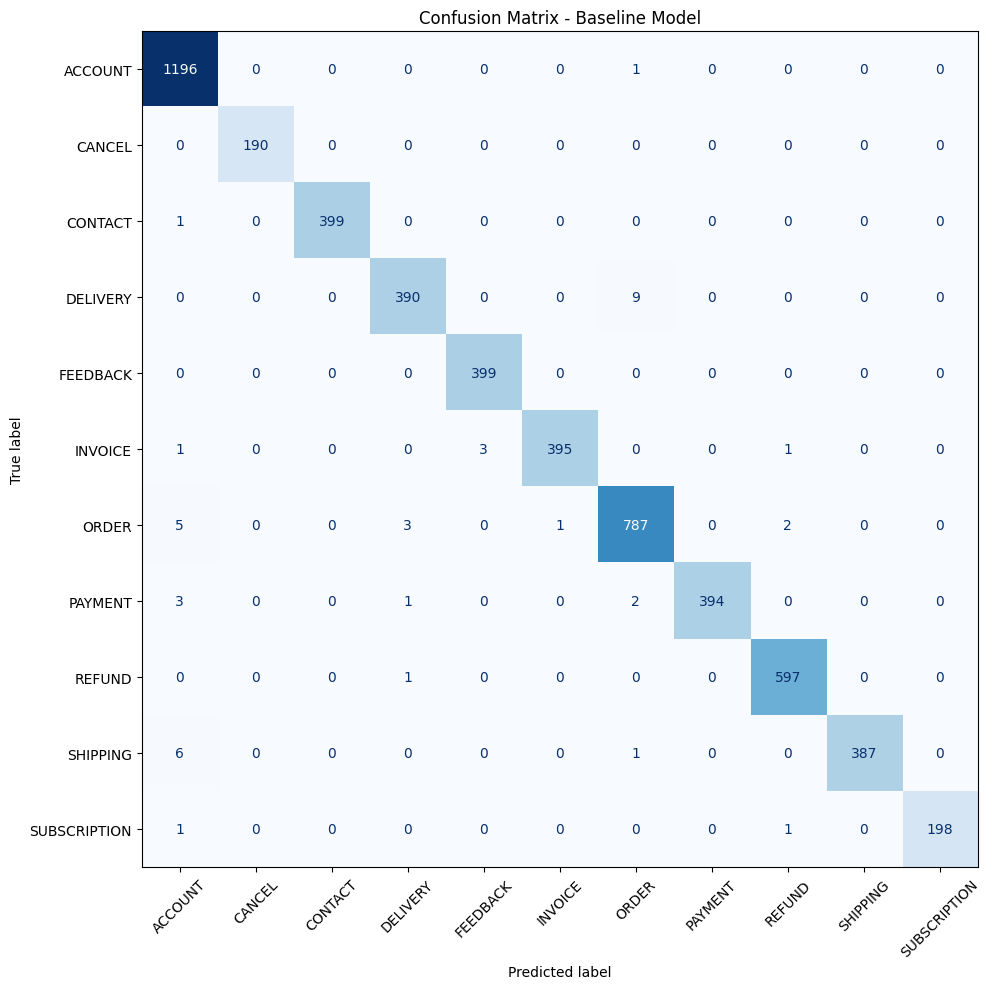

In [13]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix - Baseline Model")
plt.tight_layout()
plt.savefig("../models/confusion_matrix.png")
plt.show()

## Step 12: Hyperparameter Tuning
Grid search over regularization strength `C`. Using `cv=3` to keep runtime reasonable on ~21K training rows.

In [14]:
params = {"C": [1, 5, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=3, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_vec, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best params: {'C': 10}
Best CV accuracy: 0.9952551194005811


## Step 13: Best Model Selection

In [15]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_vec)
print("Tuned test accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

Tuned test accuracy: 0.9929302325581395
              precision    recall  f1-score   support

     ACCOUNT       0.99      1.00      1.00      1197
      CANCEL       1.00      1.00      1.00       190
     CONTACT       1.00      1.00      1.00       400
    DELIVERY       0.99      0.98      0.98       399
    FEEDBACK       0.99      1.00      1.00       399
     INVOICE       1.00      0.99      0.99       400
       ORDER       0.98      0.99      0.99       798
     PAYMENT       1.00      0.98      0.99       400
      REFUND       0.99      1.00      1.00       598
    SHIPPING       1.00      0.99      0.99       394
SUBSCRIPTION       0.99      0.99      0.99       200

    accuracy                           0.99      5375
   macro avg       0.99      0.99      0.99      5375
weighted avg       0.99      0.99      0.99      5375



## Step 14: Save the Model
Saving the model, the fitted TF-IDF vectorizer, **and** the label encoder — `app.py` needs all three: the vectorizer to featurize new text the same way, the model to predict a numeric label, and the encoder to turn that number back into a readable category name.

In [16]:
joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")
joblib.dump(label_encoder, "../models/label_encoder.pkl")
print("Saved best_model.pkl, vectorizer.pkl, label_encoder.pkl to ../models/")

Saved best_model.pkl, vectorizer.pkl, label_encoder.pkl to ../models/


## Done
Files produced in `../models/`: `best_model.pkl`, `vectorizer.pkl`, `label_encoder.pkl`, plus `wordcloud.png`, `category_distribution.png`, `confusion_matrix.png` for your presentation.

Next: run the Streamlit app:
```bash
streamlit run ../app.py
```